# 02 – Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform an exploratory data analysis (EDA) of the cleaned EUR/USD weekly dataset. The analysis aims to understand the characteristics, distribution, and temporal behavior of the exchange rate before developing forecasting models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/eur_weekly_clean.csv")

df.head()

,Date,Price,Open,High,Low,Change %
0,2000-01-02,1.0292,1.0052,1.0417,1.0050,2.15
1,2000-01-09,1.0128,1.0288,1.0370,1.0111,-1.59
2,2000-01-16,1.0091,1.0128,1.0193,1.0049,-0.37
3,2000-01-23,0.9750,1.0026,1.0101,0.9738,-3.38
4,2000-01-30,0.9828,0.9779,0.9949,0.9662,0.80


In [2]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1371 entries, 0 to 1370
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1371 non-null   datetime64[us]
 1   Price     1371 non-null   float64       
 2   Open      1371 non-null   float64       
 3   High      1371 non-null   float64       
 4   Low       1371 non-null   float64       
 5   Change %  1371 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 64.4 KB


## Visualization of the EUR/USD Closing Price

The first exploratory analysis examines the evolution of the EUR/USD weekly closing exchange rate over time. Visualizing the closing price helps identify long-term trends, periods of appreciation or depreciation, and major fluctuations in the exchange rate.

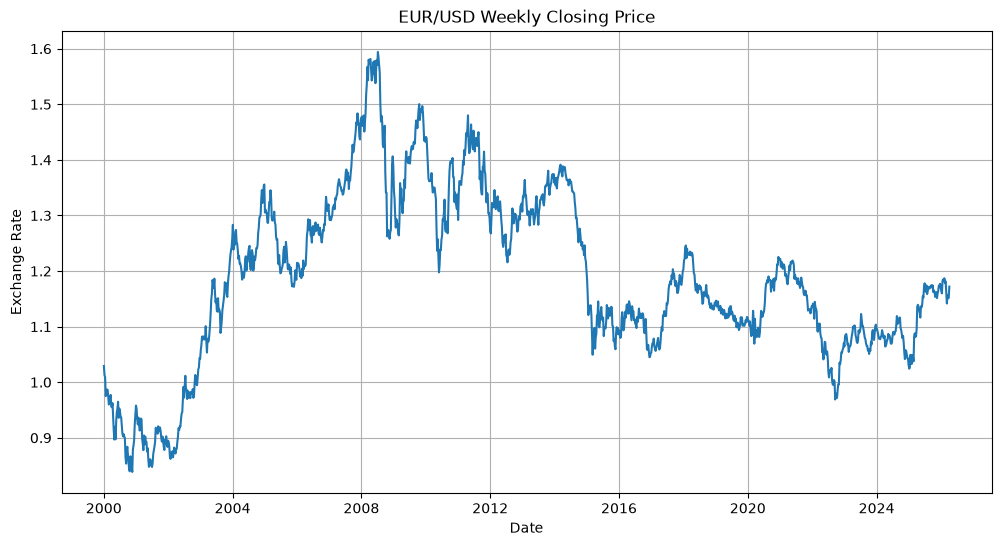

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Price"])

plt.title("EUR/USD Weekly Closing Price")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)

plt.show() 

## Interpretation of the Closing Price Trend

The line chart illustrates the weekly closing EUR/USD exchange rate over the observation period from 2000 to 2026.

Several important characteristics can be observed:

- The exchange rate exhibits clear long-term upward and downward trends.
- Periods of increased volatility are visible, particularly around 2008–2012.
- After 2015, the exchange rate fluctuates within a comparatively narrower range.
- The series does not appear to maintain a constant mean over time, suggesting that the data may not be stationary.

These observations provide valuable insights into the behavior of the exchange rate and will be considered during the selection and implementation of forecasting models.

In [4]:
plt.savefig("../outputs/figures/eurusd_closing_price.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [5]:
import os

os.listdir("../outputs/figures")

['arima_acf.png',
 'arima_first_difference.png',
 'arima_forecast.png',
 'arima_pacf.png',
 'arima_train_test_split.png',
 'correlation_matrix.png',
 'eurusd_closing_price.png',
 'eurusd_ohlc.png',
 'price_boxplot.png',
 'price_distribution.png',
 'random_forest_forecast.png']

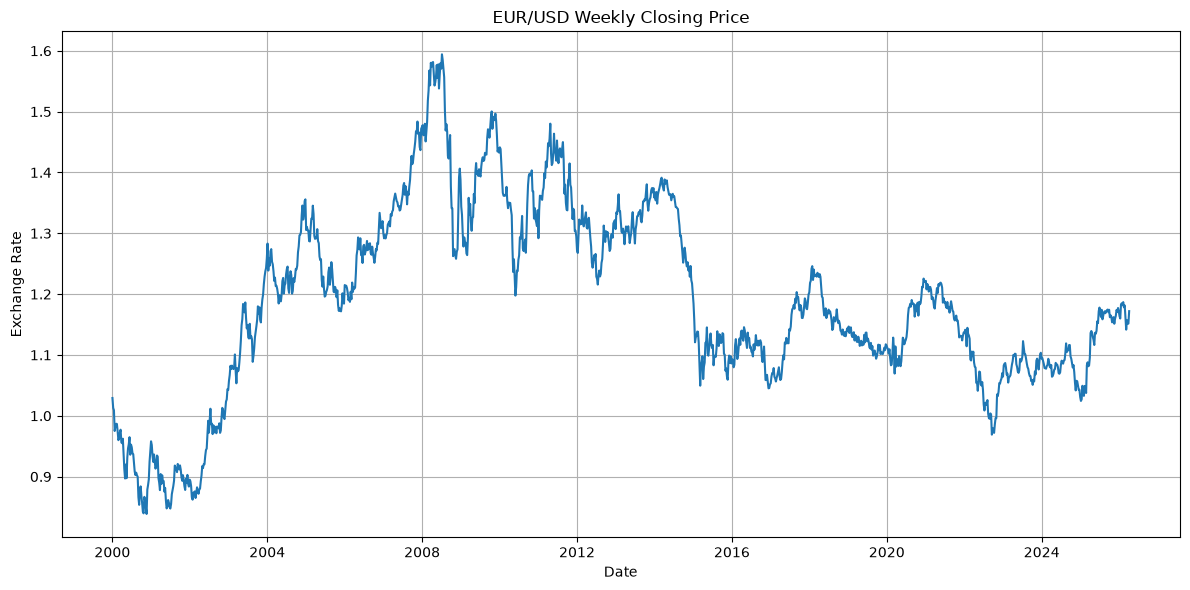

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Price"])

plt.title("EUR/USD Weekly Closing Price")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/eurusd_closing_price.png", dpi=300)

plt.show()

## Comparison of Weekly OHLC Prices

This visualization compares the weekly Open, High, Low, and Closing prices of the EUR/USD exchange rate. Examining these variables together provides insight into the weekly price movements and the relationship between different price levels over time.

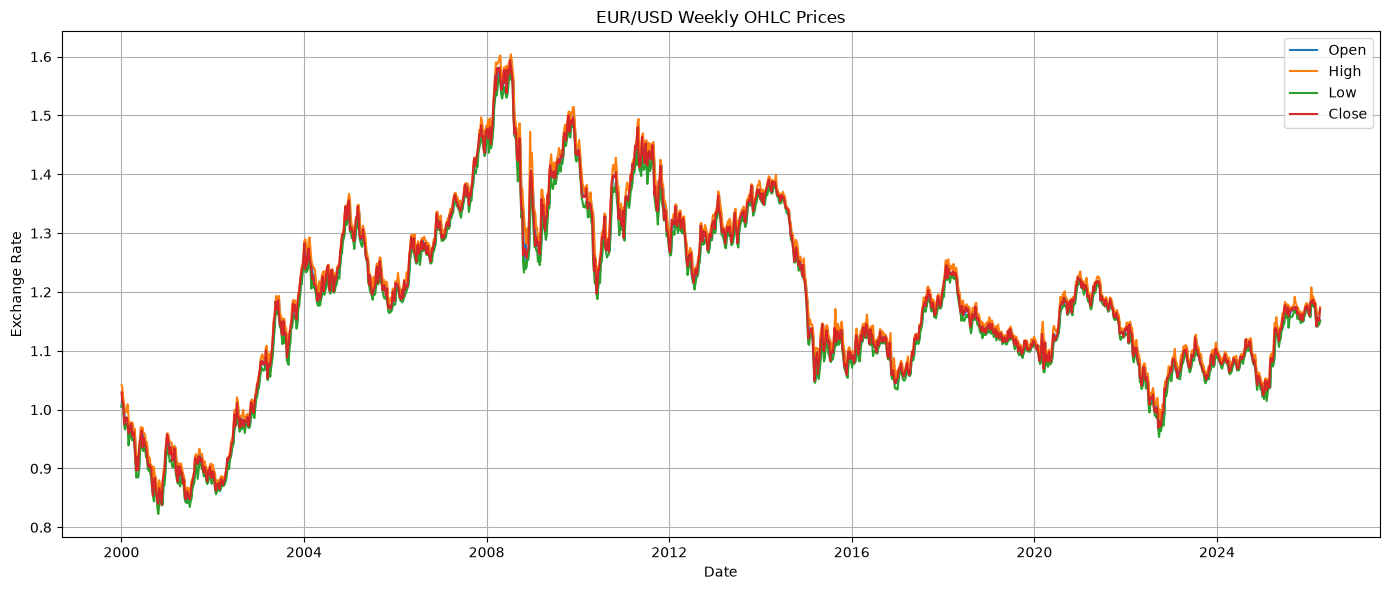

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Price"], label="Close")

plt.title("EUR/USD Weekly OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/eurusd_ohlc.png", dpi=300)

plt.show()

## Interpretation of the OHLC Price Comparison

The comparison of the weekly Open, High, Low, and Closing prices demonstrates that all 
four price series exhibit similar movement patterns throughout the observation period.
The High price consistently represents the maximum weekly exchange rate, while the Low
price represents the minimum weekly exchange rate. The Open and Closing prices 
fluctuate within this range, indicating normal market behavior.
The close alignment of the four price series suggests that the dataset is internally
consistent and suitable for subsequent feature engineering and predictive modelling.

## Distribution of the Closing Price

A histogram is used to examine the distribution of the weekly EUR/USD closing exchange rate. Understanding the distribution helps identify the concentration of values, the spread of the data, and whether the observations appear symmetric or skewed.

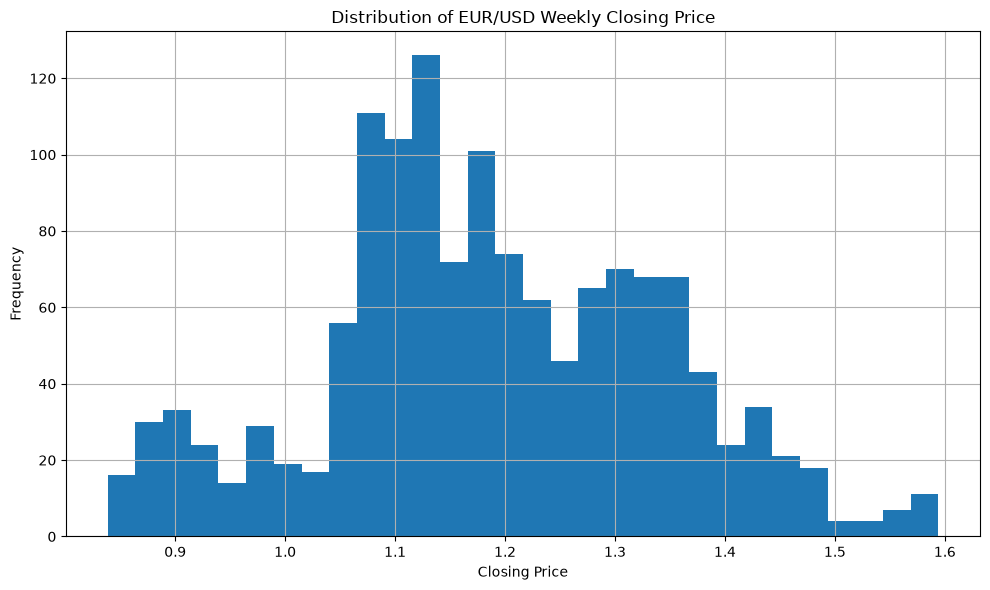

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(df["Price"], bins=30)

plt.title("Distribution of EUR/USD Weekly Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/price_distribution.png", dpi=300)

plt.show()

## Interpretation of the Price Distribution

The histogram illustrates the distribution of the weekly EUR/USD closing exchange rates over the observation period.

The majority of observations are concentrated between approximately **1.05 and 1.35**, with the highest frequency occurring around **1.10–1.20**. The distribution is not perfectly symmetric, indicating that the exchange rate spent more time within certain value ranges than others.

Only a small number of observations appear at the lowest and highest exchange rates, suggesting that extreme values are relatively uncommon. Overall, the distribution appears reasonable for financial time-series data and does not reveal any unexpected irregularities.

## Boxplot of the Closing Price

A boxplot is used to summarize the distribution of the weekly closing exchange rate and to identify potential outliers. The visualization displays the median, interquartile range, and observations that fall outside the typical range of the data.

C:\Users\anilk\AppData\Local\Temp\ipykernel_10104\3583366667.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price"], vert=True)


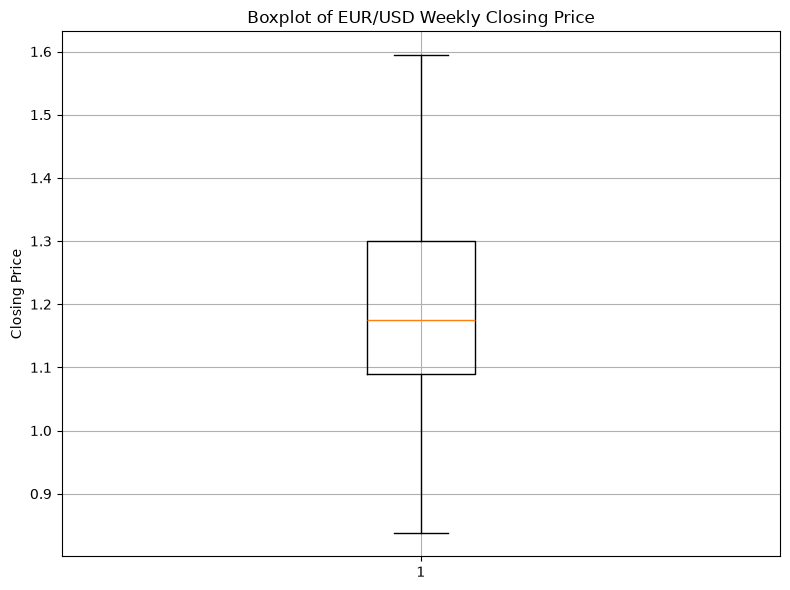

In [9]:
plt.figure(figsize=(8, 6))

plt.boxplot(df["Price"], vert=True)

plt.title("Boxplot of EUR/USD Weekly Closing Price")
plt.ylabel("Closing Price")

plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/price_boxplot.png", dpi=300)

plt.show()

## Interpretation of the Boxplot

The boxplot summarizes the distribution of the weekly EUR/USD closing exchange rate.

The median closing price is approximately **1.17**, while the middle 50% of observations are concentrated between roughly **1.09** and **1.30**. The whiskers indicate that the exchange rate ranges from approximately **0.84** to **1.59**.

No significant outliers are identified according to the boxplot. This suggests that the dataset does not contain unusually extreme observations that would require additional preprocessing before forecasting.

## Correlation Analysis

A correlation matrix is used to measure the linear relationship between the numerical variables in the dataset. Strong correlations indicate variables that move together and help identify potential predictors for forecasting models.

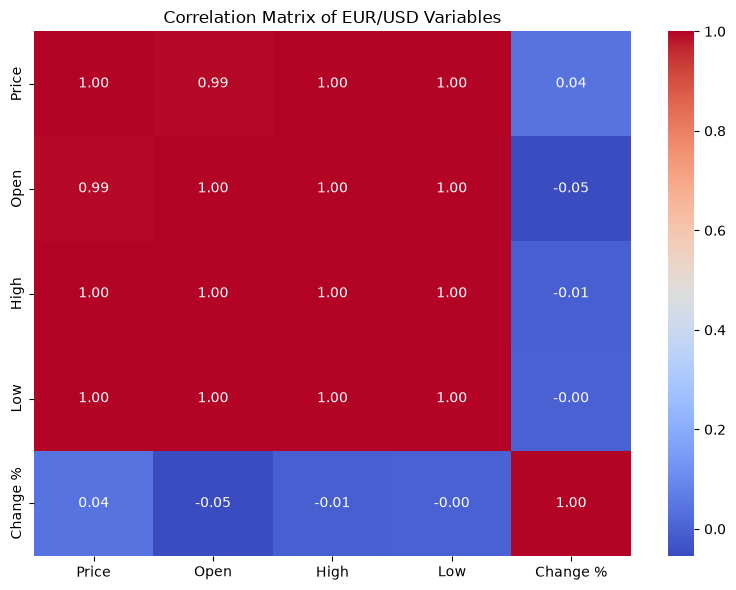

In [10]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of EUR/USD Variables")

plt.tight_layout()

plt.savefig("../outputs/figures/correlation_matrix.png", dpi=300)

plt.show()

## Interpretation of the Correlation Matrix

The correlation matrix indicates that the Open, High, Low, and Closing prices exhibit extremely strong positive correlations, with coefficients close to 1.00. This result is expected because these variables represent different price levels within the same trading week.

In contrast, the weekly percentage change demonstrates almost no linear correlation with the price variables. This suggests that the magnitude of weekly returns is largely independent of the absolute exchange rate level.

Overall, the correlation analysis confirms the consistency of the dataset and provides confidence that the variables accurately represent the weekly movements of the EUR/USD exchange rate.

## Creating Lag Features

Lag features represent previous observations of the exchange rate and are commonly used in time-series forecasting. They allow machine learning models to learn temporal dependencies by incorporating historical information into the prediction process.

In this study, lag features for one, two, and three previous weeks are created.

In [11]:
df["Lag_1"] = df["Price"].shift(1)
df["Lag_2"] = df["Price"].shift(2)
df["Lag_3"] = df["Price"].shift(3)

df[["Date", "Price", "Lag_1", "Lag_2", "Lag_3"]].head(10)

,Date,Price,Lag_1,Lag_2,Lag_3
0,2000-01-02,1.0292,NaN,NaN,NaN
1,2000-01-09,1.0128,1.0292,NaN,NaN
2,2000-01-16,1.0091,1.0128,1.0292,NaN
3,2000-01-23,0.9750,1.0091,1.0128,1.0292
4,2000-01-30,0.9828,0.9750,1.0091,1.0128
5,2000-02-06,0.9869,0.9828,0.9750,1.0091
6,2000-02-13,0.9865,0.9869,0.9828,0.9750
7,2000-02-20,0.9745,0.9865,0.9869,0.9828
8,2000-02-27,0.9599,0.9745,0.9865,0.9869
9,2000-03-05,0.9630,0.9599,0.9745,0.9865


## Creating Moving Average Features

Moving averages smooth short-term fluctuations in exchange rates by calculating the average closing price over a specified number of previous observations.

These features help machine learning models identify longer-term market trends while reducing the influence of short-term noise. In this study, 5-week, 10-week, and 20-week moving averages are created.

In [12]:
df["MA_5"] = df["Price"].rolling(window=5).mean()
df["MA_10"] = df["Price"].rolling(window=10).mean()
df["MA_20"] = df["Price"].rolling(window=20).mean()

df[["Date", "Price", "MA_5", "MA_10", "MA_20"]].head(25)

,Date,Price,MA_5,MA_10,MA_20
0,2000-01-02,1.0292,NaN,NaN,NaN
1,2000-01-09,1.0128,NaN,NaN,NaN
2,2000-01-16,1.0091,NaN,NaN,NaN
3,2000-01-23,0.9750,NaN,NaN,NaN
4,2000-01-30,0.9828,1.00178,NaN,NaN
5,2000-02-06,0.9869,0.99332,NaN,NaN
6,2000-02-13,0.9865,0.98806,NaN,NaN
7,2000-02-20,0.9745,0.98114,NaN,NaN
8,2000-02-27,0.9599,0.97812,NaN,NaN
9,2000-03-05,0.9630,0.97416,0.98797,NaN


## Creating Rolling Volatility

Rolling volatility is calculated as the rolling standard deviation of the weekly closing price over a specified time window.

Unlike moving averages, which measure the average price level, rolling volatility quantifies the variability of exchange rates over time. Higher values indicate greater market uncertainty and larger price fluctuations.

A five-week rolling standard deviation is used in this study.

In [13]:
df["Volatility_5"] = df["Price"].rolling(window=5).std()

df[["Date", "Price", "Volatility_5"]].head(15)

,Date,Price,Volatility_5
0,2000-01-02,1.0292,NaN
1,2000-01-09,1.0128,NaN
2,2000-01-16,1.0091,NaN
3,2000-01-23,0.9750,NaN
4,2000-01-30,0.9828,0.022385
5,2000-02-06,0.9869,0.016703
6,2000-02-13,0.9865,0.012695
7,2000-02-20,0.9745,0.006051
8,2000-02-27,0.9599,0.011339
9,2000-03-05,0.9630,0.012675


## Removing Missing Values Created During Feature Engineering

The creation of lag features, moving averages, and rolling volatility introduces missing values at the beginning of the dataset because previous observations are unavailable for the earliest records.

These observations are removed to produce a complete dataset suitable for machine learning and forecasting models.

In [14]:
df = df.dropna()

df.head()

,Date,Price,Open,High,Low,Change %,Lag_1,Lag_2,Lag_3,MA_5,MA_10,MA_20,Volatility_5
19,2000-05-14,0.8974,0.9177,0.9194,0.8845,-2.45,0.9199,0.8969,0.9123,0.91296,0.93877,0.963370,0.017254
20,2000-05-21,0.9312,0.8975,0.9344,0.8953,3.77,0.8974,0.9199,0.8969,0.91154,0.93465,0.958470,0.014758
21,2000-05-28,0.9465,0.9324,0.9506,0.9235,1.64,0.9312,0.8974,0.9199,0.91838,0.93159,0.955155,0.021558
22,2000-06-04,0.9532,0.9465,0.9705,0.9412,0.71,0.9465,0.9312,0.8974,0.92964,0.93129,0.952360,0.022226
23,2000-06-11,0.9648,0.9526,0.9660,0.9489,1.22,0.9532,0.9465,0.9312,0.93862,0.93228,0.951850,0.026049


In [15]:
df.isnull().sum()

Date            0
Price           0
Open            0
High            0
Low             0
Change %        0
Lag_1           0
Lag_2           0
Lag_3           0
MA_5            0
MA_10           0
MA_20           0
Volatility_5    0
dtype: int64

In [16]:
df.to_csv("../data/processed/eur_weekly_model_ready.csv", index=False)

In [17]:
df.shape

(1352, 13)

In [18]:
df.head()

,Date,Price,Open,High,Low,Change %,Lag_1,Lag_2,Lag_3,MA_5,MA_10,MA_20,Volatility_5
19,2000-05-14,0.8974,0.9177,0.9194,0.8845,-2.45,0.9199,0.8969,0.9123,0.91296,0.93877,0.963370,0.017254
20,2000-05-21,0.9312,0.8975,0.9344,0.8953,3.77,0.8974,0.9199,0.8969,0.91154,0.93465,0.958470,0.014758
21,2000-05-28,0.9465,0.9324,0.9506,0.9235,1.64,0.9312,0.8974,0.9199,0.91838,0.93159,0.955155,0.021558
22,2000-06-04,0.9532,0.9465,0.9705,0.9412,0.71,0.9465,0.9312,0.8974,0.92964,0.93129,0.952360,0.022226
23,2000-06-11,0.9648,0.9526,0.9660,0.9489,1.22,0.9532,0.9465,0.9312,0.93862,0.93228,0.951850,0.026049


# Preparing Dataset for Machine Learning Forecasting

To avoid data leakage, the target variable is shifted one week ahead so that the model predicts the next week's EUR/USD closing price using only historical information.

In [19]:
# Predict next week's closing price
df["Target"] = df["Price"].shift(-1)

In [20]:
df[["Date", "Price", "Target"]].head(10)

,Date,Price,Target
19,2000-05-14,0.8974,0.9312
20,2000-05-21,0.9312,0.9465
21,2000-05-28,0.9465,0.9532
22,2000-06-04,0.9532,0.9648
23,2000-06-11,0.9648,0.9360
24,2000-06-18,0.9360,0.9526
25,2000-06-25,0.9526,0.9484
26,2000-07-02,0.9484,0.9383
27,2000-07-09,0.9383,0.9370
28,2000-07-16,0.9370,0.9234


In [21]:
# Shift current-week market variables so they represent the previous week's information
df["Open"] = df["Open"].shift(1)
df["High"] = df["High"].shift(1)
df["Low"] = df["Low"].shift(1)
df["Change %"] = df["Change %"].shift(1)

In [22]:
df["MA_5"] = df["Price"].shift(1).rolling(window=5).mean()

df["MA_10"] = df["Price"].shift(1).rolling(window=10).mean()

df["MA_20"] = df["Price"].shift(1).rolling(window=20).mean()

df["Volatility_5"] = df["Price"].shift(1).rolling(window=5).std()

In [23]:
df = df.dropna().reset_index(drop=True)

df.shape

(1331, 14)

In [24]:
df.to_csv(
    "../data/processed/eur_weekly_model_ready_v2.csv",
    index=False
)

In [25]:
df.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Change %', 'Lag_1', 'Lag_2',
       'Lag_3', 'MA_5', 'MA_10', 'MA_20', 'Volatility_5', 'Target'],
      dtype='str')